In [20]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


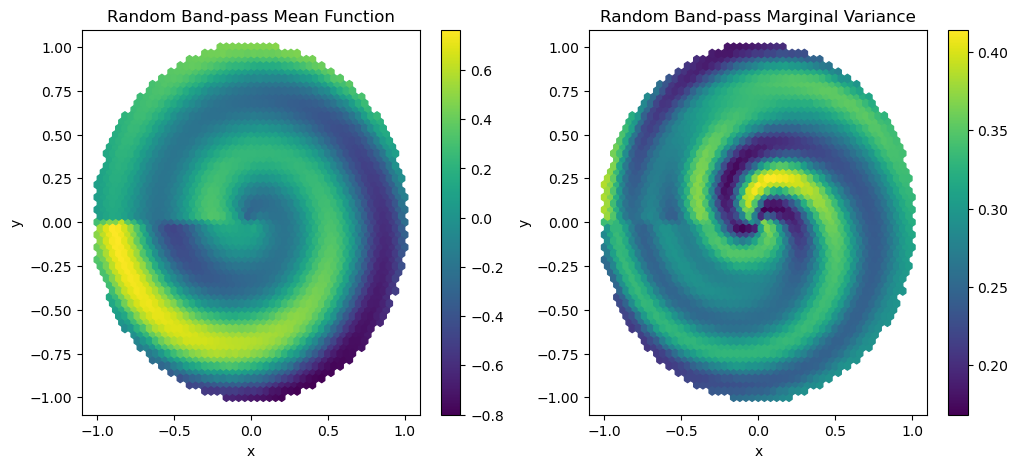

In [21]:
%autoreload 2
from infidictionary.datasets import RandomBandpassGenerator
from infidictionary.dictionaries.utils import sample_from_disk

# Example
bandpass_gen = RandomBandpassGenerator(
    radial=True,
    omega_lo=5,
    omega_hi=10,
    r_lo=0.5,
    r_hi=1.0,
    l_sin=5,
    l_cos=5,
    seed=1024,
    mean_seed=2024,
)
N = 5000_0
coords = sample_from_disk(N).to(device)
mean_function = torch.zeros(N, device=device)
marginal_variances = torch.zeros(N, device=device)
n_samples = 100
batch_size = 100

all_vals = None
for seed in range(n_samples):
    seed_batch = torch.randint(0, 1000, (batch_size,))
    vals = bandpass_gen.get_batch(coords, seeds=seed_batch).to(device)  # shape (B, N)
    all_vals = vals if all_vals is None else torch.cat([all_vals, vals], dim=0)
    
mean_function = torch.mean(all_vals, dim=0)
marginal_variances = torch.var(all_vals, dim=0)

fig, axes = plt.subplots(figsize=(12,5), nrows=1, ncols=2)
ax = axes[0]
ax.hexbin(coords.detach().cpu()[:,0], coords.detach().cpu()[:,1], C=mean_function.detach().cpu(), gridsize=50, cmap='viridis') 
ax.set_title(f'Random Band-pass Mean Function')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax = axes[1]
ax.hexbin(coords.detach().cpu()[:,0], coords.detach().cpu()[:,1], C=marginal_variances.detach().cpu(), gridsize=50, cmap='viridis') 
ax.set_title(f'Random Band-pass Marginal Variance')
ax.set_xlabel('x')
ax.set_ylabel('y')
for ax in axes:
    plt.colorbar(ax.collections[0], ax=ax)
plt.show()

In [ ]:
%autoreload 2
from infidictionary.utils import MLPNeuralField
from tqdm import tqdm
field = MLPNeuralField(
    input_dim=2, 
    output_dim=1, 
    hidden_dims=dict(
        first=128,
        second=128,
        third=128,
    ),
    activation=torch.nn.ReLU
).to(device)
 
# field = FFNeuralField(
#     input_dim=2, output_dim=1, n_features=64, sigma=10.0,
#     hidden_dims=(256,256), activation=torch.nn.ReLU,
# ).to(device)
batch_size = 128
grid_size = 10000
n_epochs = 1000

optimizer = torch.optim.Adam(field.parameters(), lr=1e-3)
loss_history = []
coords = sample_from_disk(grid_size).to(device)

pbar = tqdm(range(n_epochs))

for epoch in pbar:
    losses = []
    # take a random batch of functions
    seed_batch = torch.randint(0, 1000, (batch_size,))
    vals = bandpass_gen.get_batch(coords, seeds=seed_batch).to(device)  # shape (B, N)
    # vals = selected_vals
    pred_values = field(coords).squeeze(-1)
    # print(pred_values.shape, vals.shape)
    loss = torch.mean((vals - pred_values.unsqueeze(0)).pow(2))
    loss.backward()
    losses.append(loss.item()) 
    loss_history.append(np.mean(losses))
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_postfix({'loss': loss.item()})


100%|██████████| 1000/1000 [00:47<00:00, 21.07it/s, loss=0.00442]


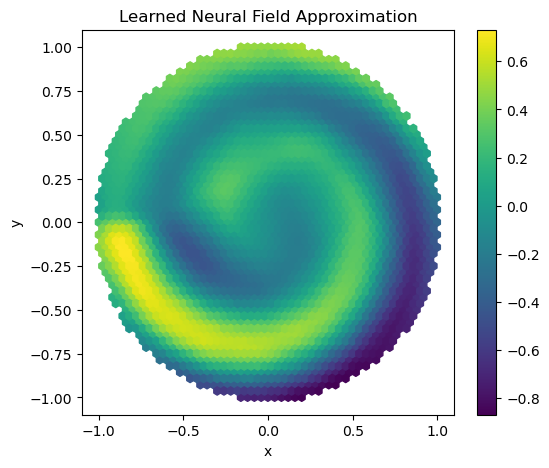

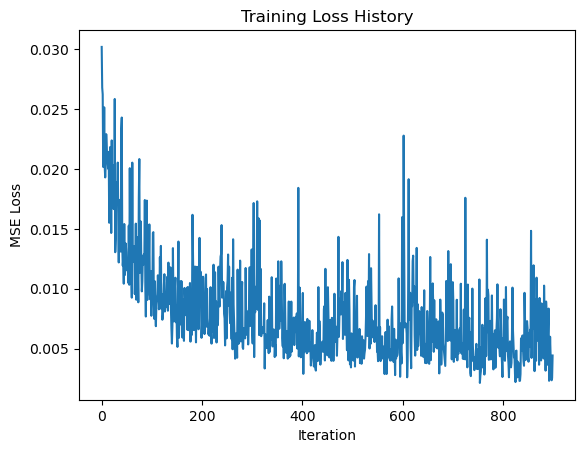

In [34]:

# visualize the learned function
fig, ax = plt.subplots(figsize=(6,5))
N = 5000_0
xy = sample_from_disk(N).to(device)
pred_values = field(xy).squeeze(-1)
ax.hexbin(xy.detach().cpu()[:,0], xy.detach().cpu()[:,1], C=pred_values.detach().cpu(), gridsize=50, cmap='viridis')
ax.set_title(f'Learned Neural Field Approximation')
ax.set_xlabel('x')
ax.set_ylabel('y')
# add colorbar
plt.colorbar(ax.collections[0], ax=ax)
plt.show()
plt.plot(loss_history[len(loss_history)//10:])
plt.title('Training Loss History')
plt.xlabel('Iteration') 
plt.ylabel('MSE Loss')
plt.show()